In [1]:
import os
import pandas as pd

model_dirs = ['scvelo_revised', 'unitvelo_revised', 'velovi', 'velovae', 'deepvelo_cui', 'topovelo_revised', 'stt_revised']
models = ['scvelo', 'unitvelo', 'velovi', 'velovae', 'deepvelo(cui)', 'topovelo', 'stt']
data_types = ['bidirect', 'radial']
noise_types = ['exp', 'pos']

results = {}

for i in range(len(models)):
    model = models[i]
    model_dir = model_dirs[i]
    results[model] = {}
    for data_type in data_types:
        results[model][data_type] = {}
        for noise_type in noise_types:
            metrics = []
            if noise_type == 'exp':
                noise_levels = ['0.1', '0.5', '1', '5', '10']
            else:
                noise_levels = ['0', '0.5', '1']
            for noise_level in noise_levels:
                path = f'../logs/{model_dir}/simulate/{data_type}/{noise_type}_noise/{noise_level}'
                for timestamp in os.listdir(path):
                    ts_path = os.path.join(path, timestamp)
                    file = 'metric_coord_redo.csv'
                    if file not in os.listdir(ts_path):
                        file = 'metric_coord.csv'
                    if file not in os.listdir(ts_path):
                        file = 'metric.csv'
                    if file not in os.listdir(ts_path):
                        continue
                    df_metric = pd.read_csv(os.path.join(ts_path, file))
                    velocity_acc = float(df_metric.loc[df_metric['Unnamed: 0'] == 'velocity_acc', '0'].values[0])
                    if model == 'scvelo':
                        time_corr_spearman = float(df_metric.loc[df_metric['Unnamed: 0'] == 'time_corr_spearman_pred_t_norm', '0'].values[0])
                        time_corr_spearman2 = float(df_metric.loc[df_metric['Unnamed: 0'] == 'time_corr_spearman_fit_t_mean', '0'].values[0])
                    elif model != 'stt':
                        time_corr_spearman = float(df_metric.loc[df_metric['Unnamed: 0'].str.startswith('time_corr_spearman'), '0'].values[0])
                        time_corr_spearman2 = None
                    else:
                        time_corr_spearman = None
                        time_corr_spearman2 = None
                    if model == 'stt':
                        spatial_velo_consist = float(df_metric.loc[df_metric['Unnamed: 0'] == 'spatial_velo_consist_stt_velocity', '0'].values[0])
                        spatial_velo_consist2 = float(df_metric.loc[df_metric['Unnamed: 0'] == 'spatial_velo_consist_vj', '0'].values[0])
                    else:
                        spatial_velo_consist = float(df_metric.loc[df_metric['Unnamed: 0'].str.startswith('spatial_velo_consist'), '0'].values[0])
                        spatial_velo_consist2 = None
                    if model == 'scvelo':
                        spatial_time_consist = float(df_metric.loc[df_metric['Unnamed: 0'] == 'spatial_time_consist_pred_t_norm', '0'].values[0])
                        spatial_time_consist2 = float(df_metric.loc[df_metric['Unnamed: 0'] == 'spatial_time_consist_fit_t_mean', '0'].values[0])
                    elif model != 'stt':
                        spatial_time_consist = float(df_metric.loc[df_metric['Unnamed: 0'].str.startswith('spatial_time_consist'), '0'].values[0])
                        spatial_time_consist2 = None
                    else:
                        spatial_time_consist = None
                        spatial_time_consist2 = None

                    row = {
                        'noise_level': float(noise_level),
                        'timestamp': timestamp,
                        'velocity_acc': velocity_acc,
                        'time_corr_spearman': time_corr_spearman,
                        'time_corr_spearman2': time_corr_spearman2,
                        'spatial_velo_consist': spatial_velo_consist,
                        'spatial_velo_consist2': spatial_velo_consist2,
                        'spatial_time_consist': spatial_time_consist,
                        'spatial_time_consist2': spatial_time_consist2
                    }
                    metrics.append(row)
            df = pd.DataFrame(metrics)
            print(model, data_type, noise_type)
            print(df)
            results[model][data_type][noise_type] = df

scvelo bidirect exp
    noise_level        timestamp  velocity_acc  time_corr_spearman  \
0           0.1  20240605_222331      0.823569            0.269928   
1           0.1  20240605_222333      0.816772            0.242135   
2           0.1  20240605_222326      0.820103            0.261307   
3           0.1  20240605_222338      0.824421            0.243391   
4           0.1  20240605_222335      0.804229            0.305852   
5           0.5  20240605_222515      0.809299            0.998179   
6           0.5  20240605_222514      0.811197           -0.038775   
7           0.5  20240605_222517      0.809582           -0.155295   
8           0.5  20240605_222510      0.810368           -0.082814   
9           0.5  20240605_222520      0.813191           -0.451722   
10          1.0  20240605_233602      0.806144           -0.318931   
11          1.0  20240605_222708      0.818814            0.997750   
12          1.0  20240605_222749      0.825342           -0.068483   


In [2]:
import sys
sys.path.append('../')
from utils.plotting import extract, my_concate, plot_metric

save_dir = '../results/results_0128/data_simu'
os.makedirs(save_dir, exist_ok=True)

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


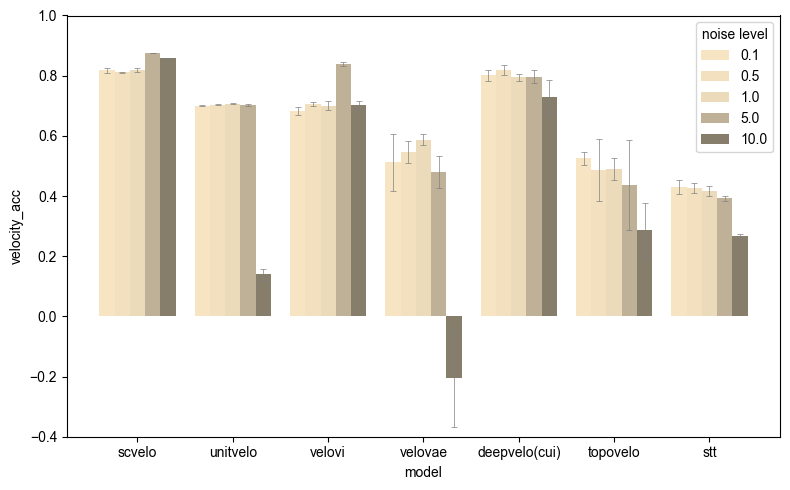

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


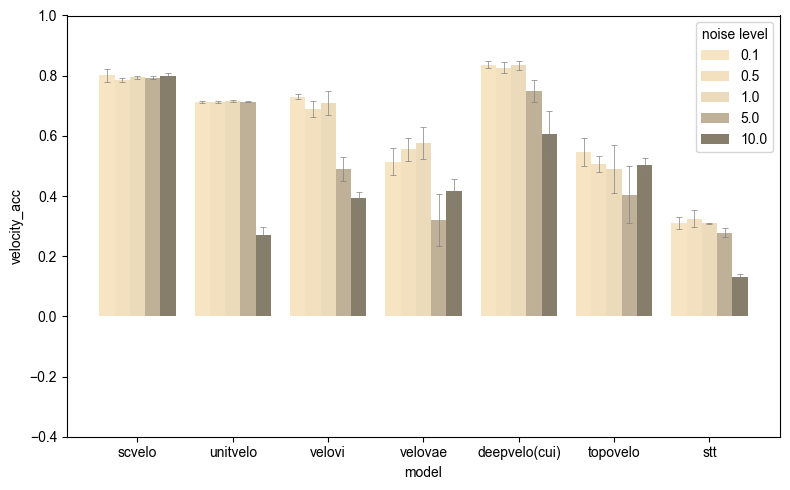

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


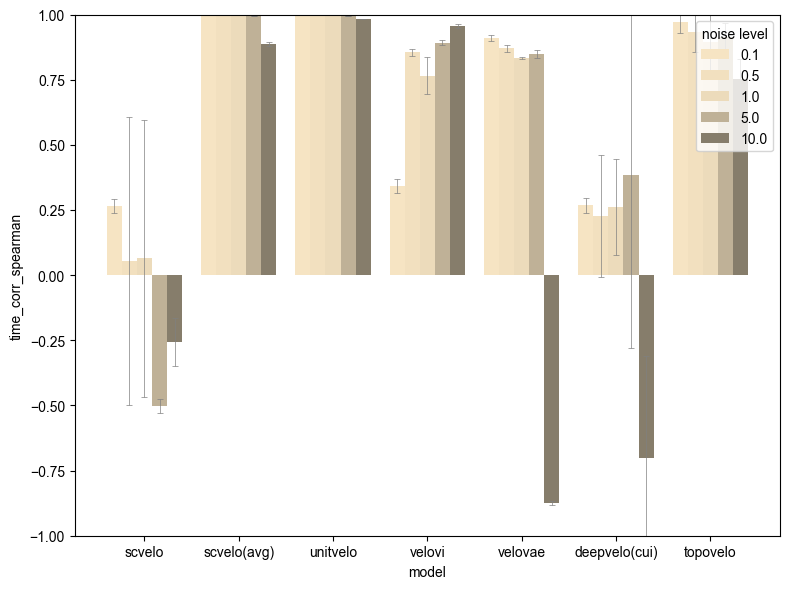

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


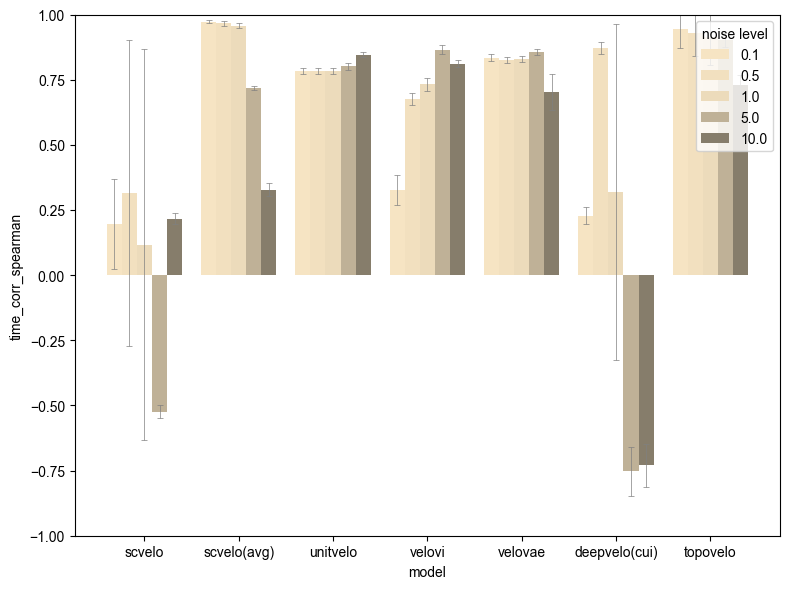

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


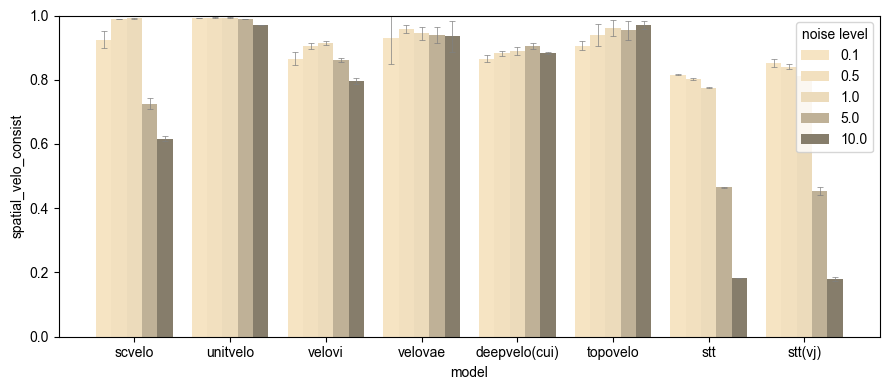

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


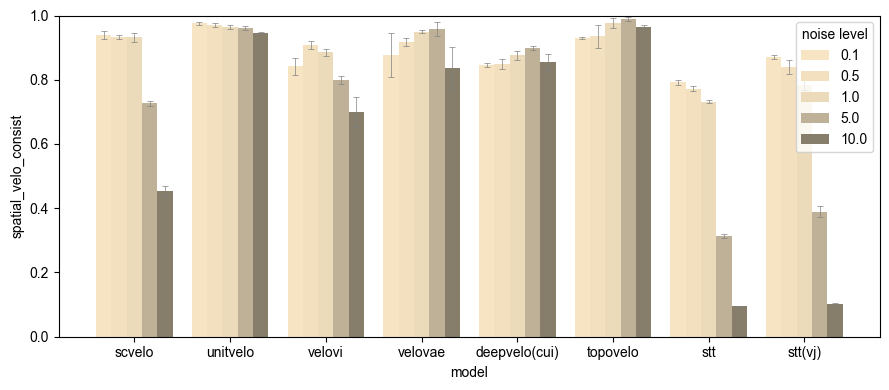

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


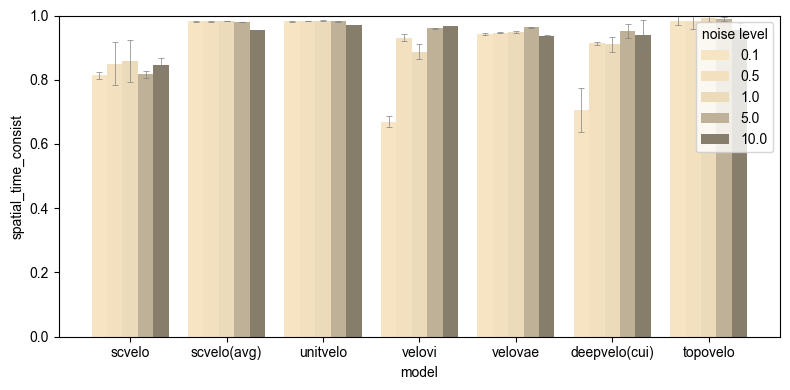

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


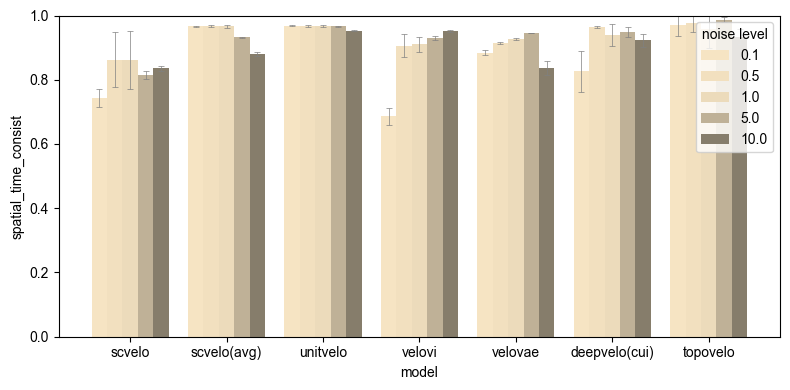

In [3]:
noise_type = 'exp'

for metric in ['velocity_acc', 'time_corr_spearman', 'spatial_velo_consist', 'spatial_time_consist']:
    for data_type in ['bidirect', 'radial']:

        df_final = pd.DataFrame()
        for model in models:
            if model == 'stt' and metric in ['time_corr_spearman', 'spatial_time_consist']:
                continue
            df = extract(results, model, data_type, noise_type, metric)
            df.columns = pd.MultiIndex.from_product([[model], df.columns])
            df_final = pd.concat([df_final, df], axis=1)
            if model == 'scvelo' and metric in ['time_corr_spearman', 'spatial_time_consist']:
                df = extract(results, model, data_type, noise_type, metric+'2')
                df.columns = pd.MultiIndex.from_product([[model+'(avg)'], df.columns])
                df_final = pd.concat([df_final, df], axis=1)
            if model == 'stt' and metric in ['spatial_velo_consist']:
                df = extract(results, model, data_type, noise_type, metric+'2')
                df.columns = pd.MultiIndex.from_product([[model+'(vj)'], df.columns])
                df_final = pd.concat([df_final, df], axis=1)
        df_cat = my_concate(df_final)

        file_name = f'{metric}_{data_type}_{noise_type}.svg'
        plot_metric(df_cat, metric, os.path.join(save_dir, file_name))

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


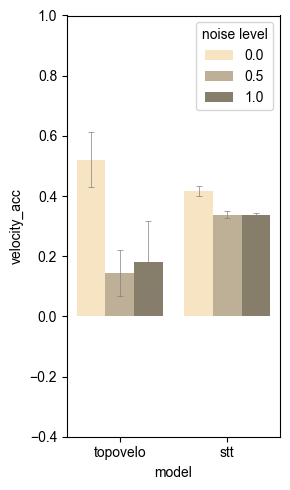

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


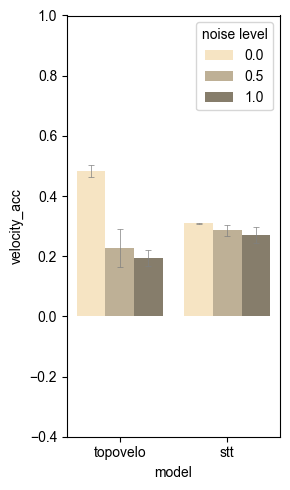

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


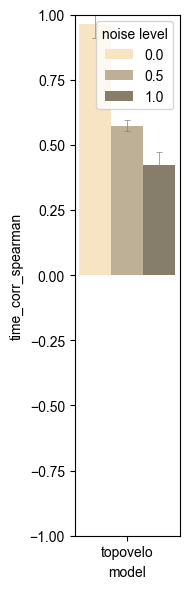

/home/nas2/biod/xueweizhi/velocity_benchmark/plot/../utils/plotting.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


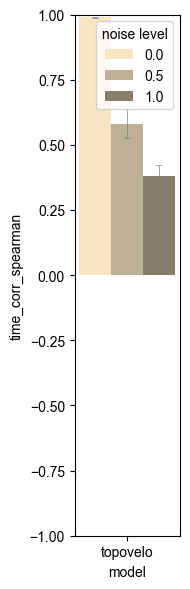

In [5]:
noise_type = 'pos'

models_pos = ['topovelo', 'stt']
for metric in ['velocity_acc', 'time_corr_spearman']:
    for data_type in ['bidirect', 'radial']:

        df_final = pd.DataFrame()
        for model in models_pos:
            if model == 'stt' and metric in ['time_corr_spearman']:
                continue
            df = extract(results, model, data_type, noise_type, metric)
            df.columns = pd.MultiIndex.from_product([[model], df.columns])
            df_final = pd.concat([df_final, df], axis=1)
        df_cat = my_concate(df_final)

        file_name = f'{metric}_{data_type}_{noise_type}.svg'
        plot_metric(df_cat, metric, os.path.join(save_dir, file_name))